In [9]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from datasets import load_from_disk, concatenate_datasets

In [10]:
# Define the base directory
base_dir = "/data/datasets/hf_cache/data/fineweb/sample-350BT/train_bge_micro_embeddings/"

# Load the dataset
embedding_dataset = concatenate_datasets(
    [
        load_from_disk(f"{base_dir}{i}")
        for i in range(8)
    ]
)

# Load the cluster assignments
assign_file = '/data/datasets/hf_cache/data/fineweb/sample-350BT/train_bge_micro_embeddings_index_1000/assignment.pkl'
with open(assign_file, 'rb') as f:
    assignments = np.array(pickle.load(f)).flatten()

# Load the cluster centroids
center_file = '/data/datasets/hf_cache/data/fineweb/sample-350BT/train_bge_micro_embeddings_index_1000/centroid.pkl'
with open(center_file, 'rb') as f:
    centroids = np.array(pickle.load(f))

In [11]:
# Randomly select 5 clusters
k_clusters = 10
selected_clusters = np.random.choice(np.unique(assignments), k_clusters, replace=False)

# Initialize variables for iterative selection
subset_size = 1000
selected_embeddings = []
selected_assignments = []

# Iteratively select embeddings until the desired subset size is reached
chunk_size = 10000
start_idx = 0
while len(selected_embeddings) < subset_size and start_idx < len(assignments):
    end_idx = min(start_idx + chunk_size, len(assignments))
    chunk_assignments = assignments[start_idx:end_idx]
    
    mask = np.isin(chunk_assignments, selected_clusters)
    filtered_indices = np.where(mask)[0]
    
    if len(filtered_indices) > 0:
        chunk_embeddings = embedding_dataset.select(range(start_idx, end_idx)).select(filtered_indices)["__embedding"]
        selected_embeddings.extend(chunk_embeddings)
        selected_assignments.extend(chunk_assignments[mask])
    
    start_idx += chunk_size

# Ensure we have exactly subset_size embeddings
selected_embeddings = np.array(selected_embeddings[:subset_size], dtype=np.float32)
selected_assignments = np.array(selected_assignments[:subset_size])

/home/emilyx/miniconda3/envs/myenv/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


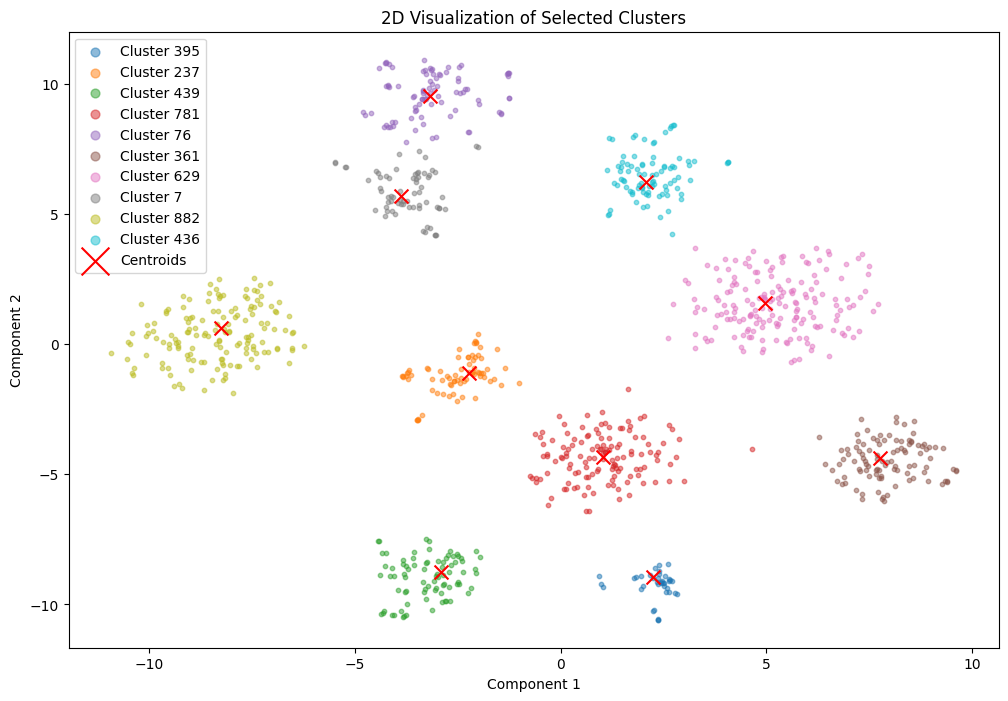

In [12]:
# Concatenate embeddings and centroids for consistent transformation
all_data = np.vstack([selected_embeddings, centroids[selected_clusters]])

# Determine the appropriate number of components for PCA
n_samples, n_features = all_data.shape
n_components = min(n_samples, n_features, 50)  # Ensure n_components is valid

# Determine the appropriate perplexity for t-SNE
perplexity = min(30, n_samples // 3)  # Ensure perplexity is less than n_samples

# Reduce dimensionality to 2D
pca = PCA(n_components=n_components)
reduced_data = pca.fit_transform(all_data)
tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=300)
data_2d = tsne.fit_transform(reduced_data)

# Separate the transformed embeddings and centroids
embeddings_2d = data_2d[:subset_size]
centroids_2d = data_2d[subset_size:]

# Plot the clusters
plt.figure(figsize=(12, 8))
for cluster_id in selected_clusters:
    cluster_points = embeddings_2d[selected_assignments == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_id}', alpha=0.5, s=10)

# Plot the centroids
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='red', marker='x', s=100, label='Centroids')

plt.title('2D Visualization of Selected Clusters')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(loc='best', markerscale=2)
plt.show()

In [13]:
# Check and print the distance to the closest centroid vs assigned centroid for the first 10 data points
for i in range(10):
    distances = np.linalg.norm(selected_embeddings[i] - centroids[selected_clusters], axis=1)
    closest_centroid = selected_clusters[np.argmin(distances)]
    assigned_centroid = selected_assignments[i]
    distance_to_closest = distances[np.argmin(distances)]
    distance_to_assigned = distances[selected_clusters.tolist().index(assigned_centroid)]
    print(f"Data point {i}:")
    print(f"  Distance to closest centroid (Cluster {closest_centroid}): {distance_to_closest}")
    print(f"  Distance to assigned centroid (Cluster {assigned_centroid}): {distance_to_assigned}")
    print()

Data point 0:
  Distance to closest centroid (Cluster 629): 0.5013953447341919
  Distance to assigned centroid (Cluster 629): 0.5013953447341919

Data point 1:
  Distance to closest centroid (Cluster 629): 0.4371258318424225
  Distance to assigned centroid (Cluster 629): 0.4371258318424225

Data point 2:
  Distance to closest centroid (Cluster 76): 0.5190675258636475
  Distance to assigned centroid (Cluster 76): 0.5190675258636475

Data point 3:
  Distance to closest centroid (Cluster 76): 0.5450795888900757
  Distance to assigned centroid (Cluster 76): 0.5450795888900757

Data point 4:
  Distance to closest centroid (Cluster 237): 0.4768799841403961
  Distance to assigned centroid (Cluster 237): 0.4768799841403961

Data point 5:
  Distance to closest centroid (Cluster 629): 0.47338491678237915
  Distance to assigned centroid (Cluster 629): 0.47338491678237915

Data point 6:
  Distance to closest centroid (Cluster 436): 0.6024877429008484
  Distance to assigned centroid (Cluster 436): 

In [14]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(selected_embeddings, selected_assignments)
print(f"Silhouette Score: {silhouette_avg}")
# score of 0.1 indicates that the clusters have high intra-cluster variance. 

Silhouette Score: 0.12213288992643356


In [15]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Function to calculate average cosine similarity within a cluster
def calculate_avg_cosine_similarity(cluster_indices, embeddings):
    avg_cosine_similarities = {}
    
    for cluster_id, indices in cluster_indices.items():
        valid_indices = indices[indices < len(embeddings)]  # Only consider indices within len(embeddings)
        if len(valid_indices) > 1:  # Need at least two points to calculate similarity
            cluster_embeddings = embeddings[valid_indices]
            cosine_sim_matrix = cosine_similarity(cluster_embeddings)
            # Calculate the average cosine similarity (excluding self-similarity)
            avg_cosine_similarity = (np.sum(cosine_sim_matrix) - len(valid_indices)) / (len(valid_indices) * (len(valid_indices) - 1))
            avg_cosine_similarities[cluster_id] = avg_cosine_similarity
        else:
            avg_cosine_similarities[cluster_id] = None  # Not enough points to calculate similarity
    
    return avg_cosine_similarities

# Assuming embeddings are stored in a variable named 'selected_embeddings'
# Example definition (replace with actual data)
# selected_embeddings = ...

# Calculate average cosine similarity within each cluster
cluster_indices = {cluster_id: np.where(selected_assignments == cluster_id)[0] for cluster_id in np.unique(selected_assignments)}
avg_cosine_similarities = calculate_avg_cosine_similarity(cluster_indices, selected_embeddings)

# Print average cosine similarities for each cluster
for cluster_id, avg_cosine_similarity in avg_cosine_similarities.items():
    if avg_cosine_similarity is not None:
        print(f"Cluster ID: {cluster_id}, Average Cosine Similarity: {avg_cosine_similarity:.4f}")
    else:
        print(f"Cluster ID: {cluster_id}, Not enough points to calculate similarity")

Cluster ID: 7, Average Cosine Similarity: 0.8391
Cluster ID: 76, Average Cosine Similarity: 0.8332
Cluster ID: 237, Average Cosine Similarity: 0.8330
Cluster ID: 361, Average Cosine Similarity: 0.8436
Cluster ID: 395, Average Cosine Similarity: 0.8134
Cluster ID: 436, Average Cosine Similarity: 0.8511
Cluster ID: 439, Average Cosine Similarity: 0.8369
Cluster ID: 629, Average Cosine Similarity: 0.8533
Cluster ID: 781, Average Cosine Similarity: 0.8537
Cluster ID: 882, Average Cosine Similarity: 0.8674


In [16]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Function to calculate cosine similarity between random points
def calculate_random_cosine_similarity(embeddings, num_pairs=10):
    random_similarities = []
    num_points = len(embeddings)
    
    for _ in range(num_pairs):
        idx1, idx2 = np.random.choice(num_points, 2, replace=False)
        point1 = embeddings[idx1].reshape(1, -1)
        point2 = embeddings[idx2].reshape(1, -1)
        similarity = cosine_similarity(point1, point2)[0][0]
        random_similarities.append(similarity)
        print(f"Cosine similarity between point {idx1} and point {idx2}: {similarity:.4f}")
    
    return random_similarities

# Assuming embeddings are stored in a variable named 'selected_embeddings'
# Example definition (replace with actual data)
# selected_embeddings = ...

# Calculate cosine similarity between random points
random_similarities = calculate_random_cosine_similarity(selected_embeddings, num_pairs=10)

# Print average cosine similarity between random points
avg_random_similarity = np.mean(random_similarities)
print(f"Average cosine similarity between random points: {avg_random_similarity:.4f}")

Cosine similarity between point 259 and point 290: 0.6570
Cosine similarity between point 682 and point 157: 0.8411
Cosine similarity between point 797 and point 54: 0.8259
Cosine similarity between point 397 and point 342: 0.8908
Cosine similarity between point 360 and point 80: 0.6619
Cosine similarity between point 720 and point 863: 0.6974
Cosine similarity between point 141 and point 992: 0.7607
Cosine similarity between point 422 and point 697: 0.8113
Cosine similarity between point 956 and point 244: 0.7220
Cosine similarity between point 407 and point 633: 0.8401
Average cosine similarity between random points: 0.7708
